In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [1]:
# Load data, display first few rows
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/mental_health_tech_ml.csv")

df_ml.head()

,Age,self_employed,family_history,treatment,remote_work,tech_company,obs_consequence,Age__missing,Gender__missing,self_employed__missing,work_interfere__missing,Gender_female,Gender_male,work_interfere_Never,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,no_employees_1-5,no_employees_100-500,no_employees_26-100,no_employees_500-1000,no_employees_6-25,no_employees_More than 1000,benefits_Don't know,benefits_No,benefits_Yes,care_options_No,care_options_Not sure,care_options_Yes,wellness_program_Don't know,wellness_program_No,wellness_program_Yes,seek_help_Don't know,seek_help_No,seek_help_Yes,anonymity_Don't know,anonymity_No,anonymity_Yes,leave_Don't know,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_Maybe,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_Maybe,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_No,coworkers_Some of them,coworkers_Yes,supervisor_No,supervisor_Some of them,supervisor_Yes,mental_health_interview_Maybe,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_Maybe,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_Don't know,mental_vs_physical_No,mental_vs_physical_Yes
0,37.0,0.0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,1
1,44.0,0.0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0
2,32.0,0.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0
3,31.0,0.0,1,1,0,1,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0
4,31.0,0.0,0,0,1,1,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,1,0,0


In [2]:
# Target variable: work interference + treatment
# Exclude rows where the original target-defining variables were missing
df = df_ml.copy()

# Keep only rows with observed work_interfere and treatment
if "work_interfere__missing" in df.columns:
    df = df[df["work_interfere__missing"] == 0].copy()

if "treatment__missing" in df.columns:
    df = df[df["treatment__missing"] == 0].copy()

# Create binary work interference variable
# 0 = Never
# 1 = Rarely / Sometimes / Often
df["work_interfere_binary"] = (
    df[[
        "work_interfere_Rarely",
        "work_interfere_Sometimes",
        "work_interfere_Often"
    ]].sum(axis=1) > 0
).astype(int)

# Create combined target variable:
# 0 = no interference
# 1 = interference but no treatment
# 2 = interference + treatment
df["combined_target"] = np.select(
    [
        df["work_interfere_Never"] == 1,
        (df["work_interfere_binary"] == 1) & (df["treatment"] == 0),
        (df["work_interfere_binary"] == 1) & (df["treatment"] == 1),
    ],
    [0, 1, 2],
    default=np.nan
)

# Drop any rows that still do not have a valid target
df = df.dropna(subset=["combined_target"]).copy()
df["combined_target"] = df["combined_target"].astype(int)

# Define predictors and target
# Remove:
# - target variable
# - target-defining variables (to avoid leakage)
# - missingness indicators for target-defining variables
X = df.drop(columns=[
    "combined_target",
    "treatment",
    "work_interfere_Never",
    "work_interfere_Rarely",
    "work_interfere_Sometimes",
    "work_interfere_Often",
    "work_interfere__missing",
    "work_interfere_binary",
    "treatment__missing"
], errors="ignore")

# Reference categories to drop (one per categorical group)
# Choice: drop the "baseline" or most common category per group
REFERENCE_COLS = [
    "Gender_male",                          # reference: male
    "no_employees_1-5",                     # reference: smallest company
    "benefits_No",                          # reference: no benefits
    "care_options_No",                      # reference: no care options
    "wellness_program_No",                  # reference: no wellness program
    "seek_help_No",                         # reference: no seek help info
    "anonymity_No",                         # reference: no anonymity
    "leave_Very difficult",                 # reference: hardest to take leave
    "mental_health_consequence_No",         # reference: no consequence
    "phys_health_consequence_No",
    "coworkers_No",
    "supervisor_No",
    "mental_health_interview_No",
    "phys_health_interview_No",
    "mental_vs_physical_No",
]

X = X.drop(columns=REFERENCE_COLS, errors="ignore")

y = df["combined_target"]

# Check final class distribution
print(y.value_counts())
print(y.value_counts(normalize=True))
print(X.shape, y.shape)

combined_target
2    603
0    213
1    179
Name: count, dtype: int64
combined_target
2    0.606030
0    0.214070
1    0.179899
Name: proportion, dtype: float64
(995, 43) (995,)


In [4]:
# Should be 0
print(df["combined_target"].isna().sum())

# Every row must belong to exactly one class
print(df["combined_target"].value_counts().sum(), len(df))

0
995 995


In [5]:
# Result means:
# 21.4% employees have no work interference (class 0), meaning they do not experience mental health issues that interfere with work.
# 60% employees have work interference and seek treatment (class 2)
# 18% employees experience work interference but do not seek treatment (class 1)
df["combined_target"].value_counts(normalize=True)

combined_target
2    0.606030
0    0.214070
1    0.179899
Name: proportion, dtype: float64

In [6]:
# Import function to split dataset into training and testing subsets
from sklearn.model_selection import train_test_split

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Split data into training and test sets
# - 80% training, 20% testing
# - stratify=y ensures class distribution is preserved in both sets
# - random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Initialize Logistic Regression model
# - solver="lbfgs" is suitable for small/medium datasets
# - max_iter increased to ensure convergence
# - class_weight="balanced" handles class imbalance
# - random_state ensures reproducibility
logreg = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

# Train the model on the training data
logreg.fit(X_train, y_train)

# Generate predicted class labels for the test set
y_pred = logreg.predict(X_test)

# Generate predicted class probabilities for the test set
# (used for metrics like ROC-AUC, calibration, etc.)
y_prob = logreg.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.44      0.58      0.50        43
           1       0.30      0.47      0.37        36
           2       0.80      0.57      0.66       120

    accuracy                           0.55       199
   macro avg       0.51      0.54      0.51       199
weighted avg       0.63      0.55      0.57       199

Macro F1: 0.5096686773319347
Weighted F1: 0.5742263639203097


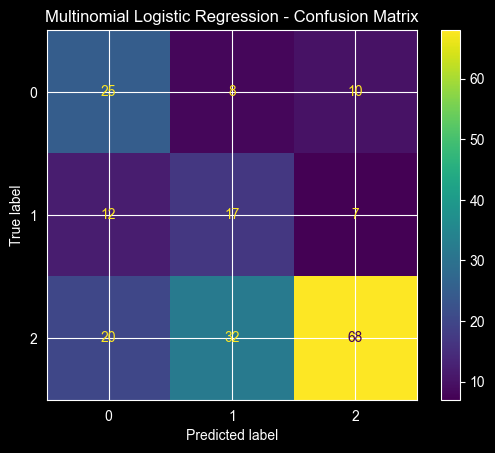

In [7]:
# Evaluation
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification report
print(classification_report(y_test, y_pred))

# F1-score
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Multinomial Logistic Regression - Confusion Matrix")
plt.show()

In [8]:
# Import Random Forest classifier (ensemble tree-based model)
from sklearn.ensemble import RandomForestClassifier

# Import function to split dataset into training and testing subsets
from sklearn.model_selection import train_test_split

# Split data into training and test sets
# - 80% training, 20% testing
# - stratify=y preserves class distribution (important for imbalanced data)
# - random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Initialize Random Forest model
# - n_estimators: number of trees in the forest (higher → more stable but slower)
# - max_depth=None: trees grow fully unless constrained
# - min_samples_split: minimum samples required to split a node (controls overfitting)
# - min_samples_leaf: minimum samples in a leaf node (smooths predictions)
# - class_weight="balanced": adjusts for class imbalance
# - random_state: ensures reproducibility
# - n_jobs=-1: use all available CPU cores for faster training
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest model on the training data
rf.fit(X_train, y_train)

# Generate predicted class labels for the test set
y_pred_rf = rf.predict(X_test)

# Generate predicted class probabilities for the test set
# (useful for ROC-AUC, calibration plots, threshold tuning, etc.)
y_prob_rf = rf.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.40      0.37      0.39        43
           1       0.42      0.28      0.33        36
           2       0.71      0.80      0.75       120

    accuracy                           0.61       199
   macro avg       0.51      0.48      0.49       199
weighted avg       0.59      0.61      0.60       199

Random Forest Macro F1: 0.4906055594928735
Random Forest Weighted F1: 0.5976444946205157


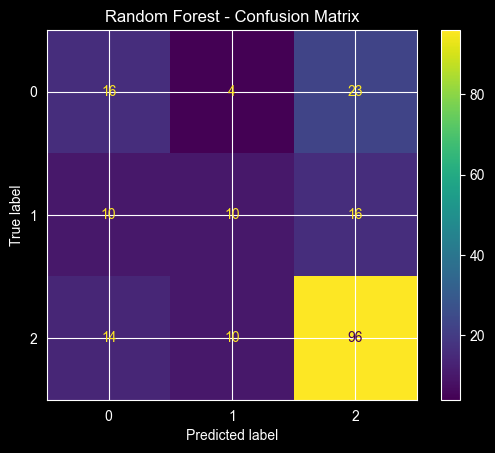

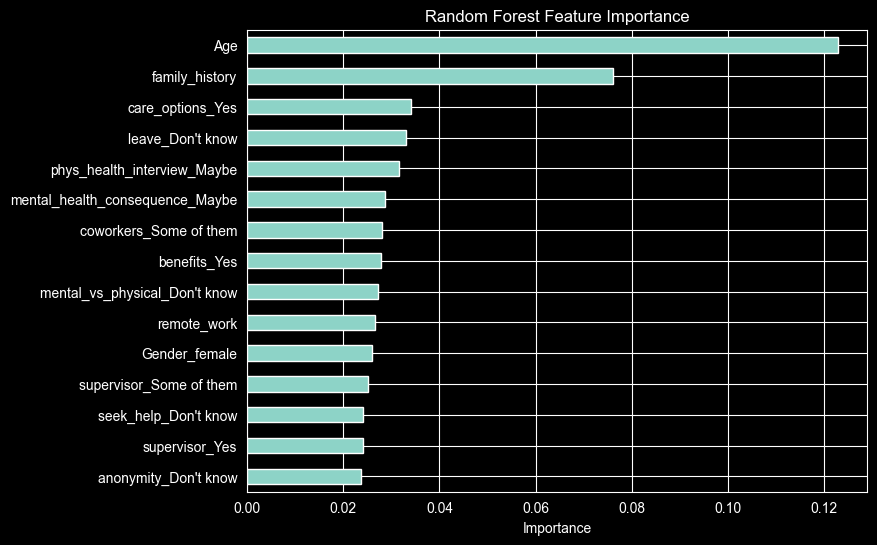

In [9]:
# Import evaluation metrics and visualization tools
# - classification_report: precision, recall, F1 per class
# - f1_score: overall F1 metrics
# - ConfusionMatrixDisplay: visualize prediction performance
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

# Import plotting library
import matplotlib.pyplot as plt

# Import pandas for handling feature importance
import pandas as pd

# Print detailed classification metrics (precision, recall, F1-score, support)
print(classification_report(y_test, y_pred_rf))

# Compute macro F1 score
# - treats all classes equally (good for imbalance insight)
macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")

# Compute weighted F1 score
# - accounts for class imbalance by weighting by class frequency
weighted_f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

# Print F1 scores
print("Random Forest Macro F1:", macro_f1_rf)
print("Random Forest Weighted F1:", weighted_f1_rf)

# Plot confusion matrix
# - shows correct vs incorrect predictions per class
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Extract feature importance from the trained Random Forest model
# - importance reflects contribution of each feature to predictions
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Display top 15 most important features
feature_importance.head(15)

# Plot top 15 features (horizontal bar chart)
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

# Add plot labels
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

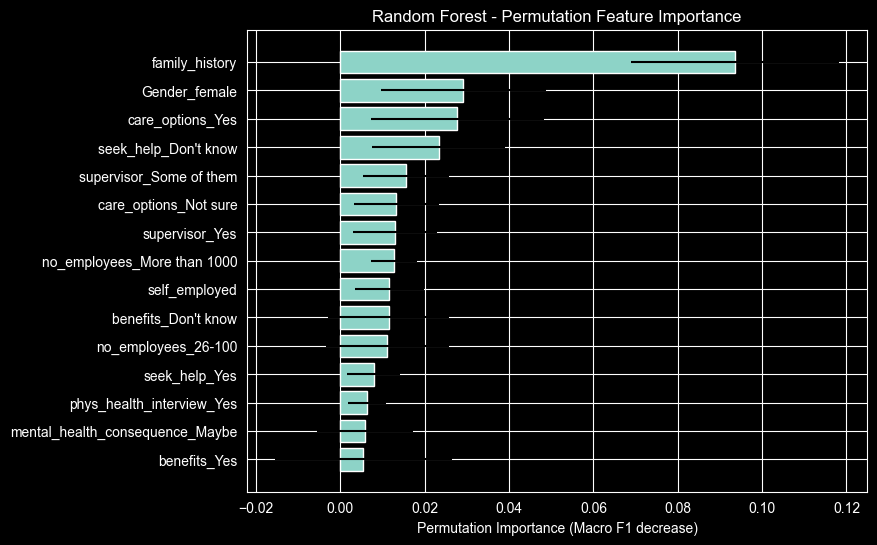

In [10]:
# Import permutation importance (model-agnostic feature importance)
# and plotting library
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Compute permutation importance on the test set
# - n_repeats: number of times each feature is shuffled (stability)
# - scoring="f1_macro": evaluates impact on macro F1 score
# - n_jobs=-1: use all CPU cores for faster computation
perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

# Create a DataFrame with mean and standard deviation of importance
# - importance_mean: average decrease in performance when feature is shuffled
# - importance_std: variability across repetitions
perm_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

# Display top 15 most important features
perm_importance_df.head(15)

# Select top 15 features and sort for horizontal plotting
top_features = perm_importance_df.head(15).sort_values("importance_mean")

# Create horizontal bar plot
# - xerr shows variability (standard deviation)
plt.figure(figsize=(8,6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

# Label plot
plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("Random Forest - Permutation Feature Importance")

# Display plot
plt.show()

In [11]:
# Import XGBoost classifier (gradient boosting model)
from xgboost import XGBClassifier

# Initialize XGBoost model
# - objective="multi:softprob": outputs class probabilities for multiclass classification
# - num_class=3: number of target classes (e.g., 0, 1, 2)
# - n_estimators: number of boosting rounds (trees)
# - max_depth: maximum depth of each tree (controls model complexity)
# - learning_rate: step size shrinkage (lower = slower but more robust learning)
# - subsample: fraction of training samples used per tree (reduces overfitting)
# - colsample_bytree: fraction of features used per tree (adds randomness)
# - reg_alpha: L1 regularization (sparsity)
# - reg_lambda: L2 regularization (stability)
# - random_state: ensures reproducibility
# - eval_metric="mlogloss": evaluation metric for multiclass classification
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="mlogloss"
)

# Train the XGBoost model on the training data
xgb.fit(X_train, y_train)

# Generate predicted class labels for the test set
y_pred_xgb = xgb.predict(X_test)

# Generate predicted class probabilities for the test set
# (used for ROC-AUC, calibration, threshold analysis, etc.)
y_prob_xgb = xgb.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.47      0.35      0.40        43
           1       0.30      0.17      0.21        36
           2       0.69      0.84      0.76       120

    accuracy                           0.61       199
   macro avg       0.49      0.45      0.46       199
weighted avg       0.57      0.61      0.58       199

XGBoost Macro F1: 0.45694667380060644
XGBoost Weighted F1: 0.5814110681820015


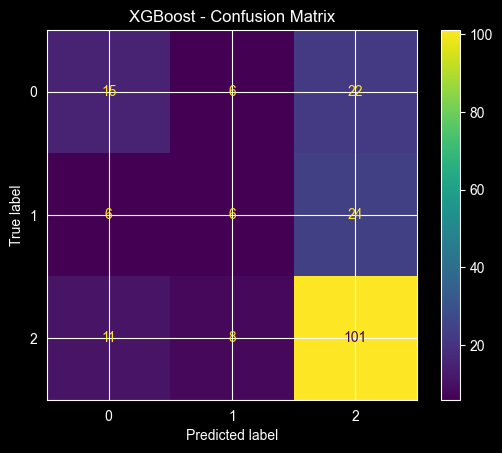

In [12]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_xgb))

macro_f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
weighted_f1_xgb = f1_score(y_test, y_pred_xgb, average="weighted")

print("XGBoost Macro F1:", macro_f1_xgb)
print("XGBoost Weighted F1:", weighted_f1_xgb)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost - Confusion Matrix")
plt.show()

family_history                     0.065429
care_options_Yes                   0.038250
Gender_female                      0.030143
anonymity_Yes                      0.029157
benefits_Yes                       0.028283
leave_Don't know                   0.026299
mental_health_consequence_Yes      0.025627
no_employees_500-1000              0.024779
wellness_program_Yes               0.024647
mental_health_consequence_Maybe    0.024185
leave_Somewhat difficult           0.024098
seek_help_Don't know               0.023791
obs_consequence                    0.023254
anonymity_Don't know               0.023132
benefits_Don't know                0.022792
dtype: float32


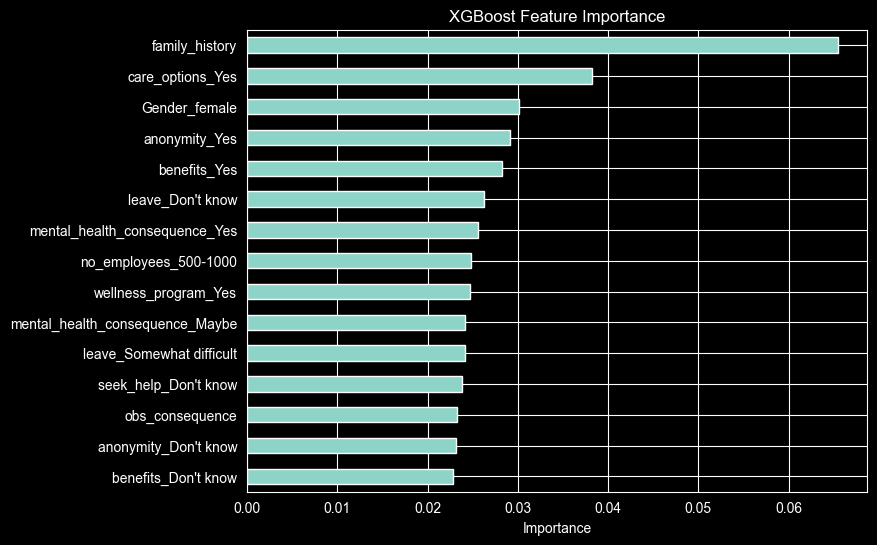

In [13]:
# Import pandas for handling feature importance as a Series
import pandas as pd

# Extract feature importance scores from the trained XGBoost model
# - feature_importances_ reflects the relative importance of each feature
# - index=X.columns aligns importance values with feature names
# - sort_values: rank features from most to least important
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Print the top 15 most important features
print(xgb_importance.head(15))

# Plot the top 15 features as a horizontal bar chart
# - sorted ascending for better visual ordering (largest at top)
# - figsize controls plot size
xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

# Add title and axis label
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

# Display the plot
plt.show()

D:\Diana\Anul III\BachelorArbeit\WellBeingModelling\venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


                          feature  importance_mean  importance_std
2                  family_history         0.077781        0.021858
16                   benefits_Yes         0.028506        0.013160
18               care_options_Yes         0.027489        0.014348
9                   Gender_female         0.022070        0.014910
21           seek_help_Don't know         0.014199        0.015738
15            benefits_Don't know         0.011358        0.012922
31  phys_health_consequence_Maybe         0.010970        0.013585
25               leave_Don't know         0.009240        0.020907
17          care_options_Not sure         0.006271        0.010604
1                   self_employed         0.006168        0.006451
28                leave_Very easy         0.004551        0.009802
10           no_employees_100-500         0.003854        0.005709
35        supervisor_Some of them         0.001666        0.013269
5                 obs_consequence         0.001170        0.00

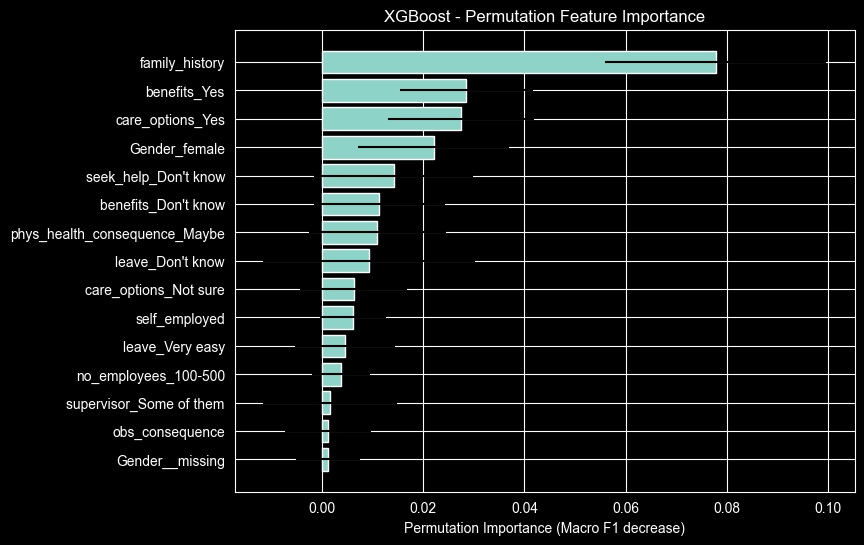

In [14]:
# Import permutation importance (model-agnostic feature importance method)
from sklearn.inspection import permutation_importance

# Compute permutation importance for the XGBoost model
# - Measures decrease in model performance when each feature is shuffled
# - n_repeats=20 improves stability of importance estimates
# - scoring="f1_macro" evaluates impact using macro F1 score
# - n_jobs=-1 uses all CPU cores for faster computation
perm_xgb = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

# Create a DataFrame with mean and standard deviation of importance scores
# - importance_mean: average decrease in performance
# - importance_std: variability across repetitions
perm_xgb_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)

# Print top 15 most important features
print(perm_xgb_df.head(15))

# Select top 15 features and sort for horizontal plotting
top_features = perm_xgb_df.head(15).sort_values("importance_mean")

# Plot permutation importance as horizontal bar chart
# - xerr displays variability (standard deviation)
plt.figure(figsize=(8, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

# Add axis label and title
plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("XGBoost - Permutation Feature Importance")

# Display plot
plt.show()

In [15]:
# Import Decision Tree classifier (interpretable tree-based model)
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree model
# - max_depth: limits tree depth to prevent overfitting
# - min_samples_split: minimum samples required to split a node (controls complexity)
# - min_samples_leaf: minimum samples in a leaf node (smooths predictions)
# - class_weight="balanced": adjusts for class imbalance
# - random_state: ensures reproducibility
tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

# Train the Decision Tree model on the training data
tree.fit(X_train, y_train)

# Generate predicted class labels for the test set
y_pred_tree = tree.predict(X_test)

# Generate predicted class probabilities for the test set
# (useful for ROC-AUC, calibration, and threshold-based analysis)
y_prob_tree = tree.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.36      0.63      0.45        43
           1       0.28      0.31      0.29        36
           2       0.76      0.53      0.63       120

    accuracy                           0.51       199
   macro avg       0.47      0.49      0.46       199
weighted avg       0.59      0.51      0.53       199

Decision Tree Macro F1: 0.4581886087768441
Decision Tree Weighted F1: 0.5294810185380685


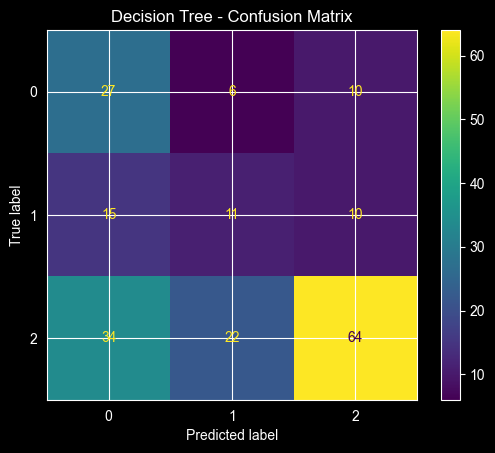

In [16]:
# Import evaluation metrics and visualization tools
# - classification_report: detailed metrics per class (precision, recall, F1)
# - f1_score: overall F1 metrics
# - ConfusionMatrixDisplay: visualizes prediction performance
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

# Import plotting library
import matplotlib.pyplot as plt

# Print classification report for Decision Tree predictions
# Includes precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_tree))

# Compute macro F1 score
# - treats all classes equally (useful for imbalanced datasets)
macro_f1_tree = f1_score(y_test, y_pred_tree, average="macro")

# Compute weighted F1 score
# - accounts for class imbalance by weighting by class frequency
weighted_f1_tree = f1_score(y_test, y_pred_tree, average="weighted")

# Print F1 scores
print("Decision Tree Macro F1:", macro_f1_tree)
print("Decision Tree Weighted F1:", weighted_f1_tree)

# Plot confusion matrix
# - shows correct vs incorrect predictions across classes
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

family_history                   0.202094
Age                              0.176336
leave_Don't know                 0.091591
care_options_Yes                 0.072468
care_options_Not sure            0.049485
supervisor_Yes                   0.045745
seek_help_Don't know             0.039154
anonymity_Yes                    0.036492
remote_work                      0.029376
wellness_program_Yes             0.027066
no_employees_26-100              0.023605
anonymity_Don't know             0.022609
mental_vs_physical_Don't know    0.022059
Gender_female                    0.020699
no_employees_More than 1000      0.020026
dtype: float64


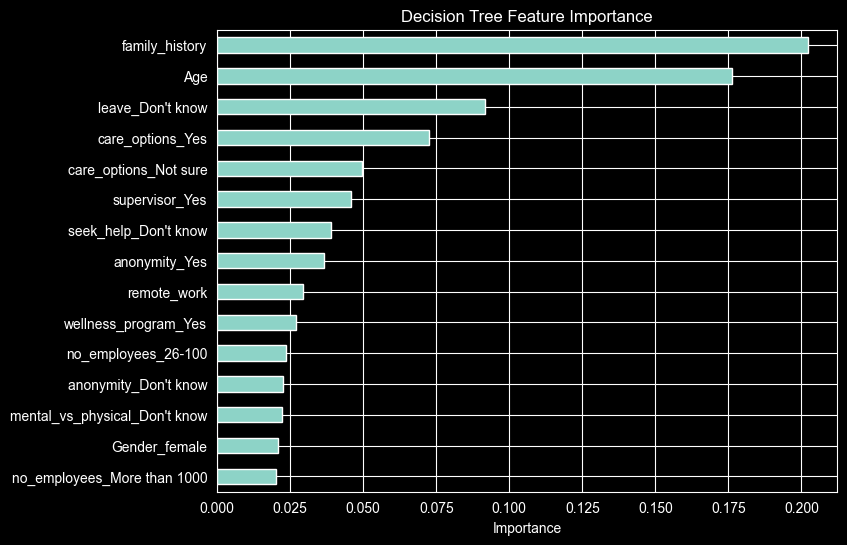

In [17]:
# Import pandas to handle feature importance as a Series
import pandas as pd

# Extract feature importance from the trained Decision Tree model
# - feature_importances_ reflects how much each feature contributes to splits
# - index=X.columns assigns feature names
# - sort_values ranks features from most to least important
tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Print top 15 most important features
print(tree_importance.head(15))

# Plot top 15 features as a horizontal bar chart
# - sorted ascending for better visual ordering (largest at top)
tree_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

# Add plot title and axis label
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")

# Display the plot
plt.show()

                        feature  importance_mean  importance_std
2                family_history         0.108670        0.028458
25             leave_Don't know         0.025688        0.018665
3                   remote_work         0.011491        0.006215
9                 Gender_female         0.011019        0.008694
10         no_employees_100-500         0.010962        0.005379
18             care_options_Yes         0.010544        0.011849
40    phys_health_interview_Yes         0.010164        0.005980
23         anonymity_Don't know         0.010161        0.005544
36               supervisor_Yes         0.008527        0.013046
19  wellness_program_Don't know         0.008190        0.006568
21         seek_help_Don't know         0.008019        0.021129
17        care_options_Not sure         0.006673        0.004091
33       coworkers_Some of them         0.000879        0.001522
35      supervisor_Some of them         0.000767        0.005434
5               obs_conse

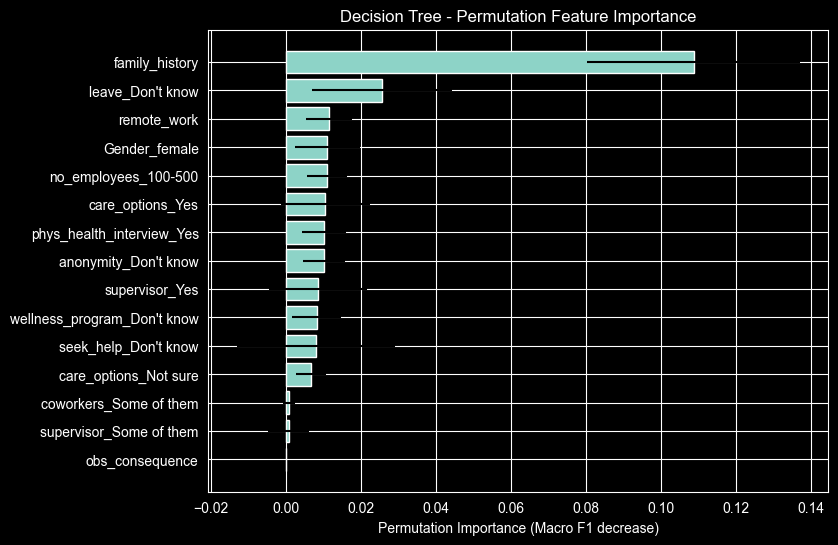

In [21]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

perm_tree = permutation_importance(
    tree,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_tree_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_tree.importances_mean,
    "importance_std": perm_tree.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_tree_df.head(15))

top_features_tree = perm_tree_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(
    top_features_tree["feature"],
    top_features_tree["importance_mean"],
    xerr=top_features_tree["importance_std"]
)
plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("Decision Tree - Permutation Feature Importance")
plt.show()

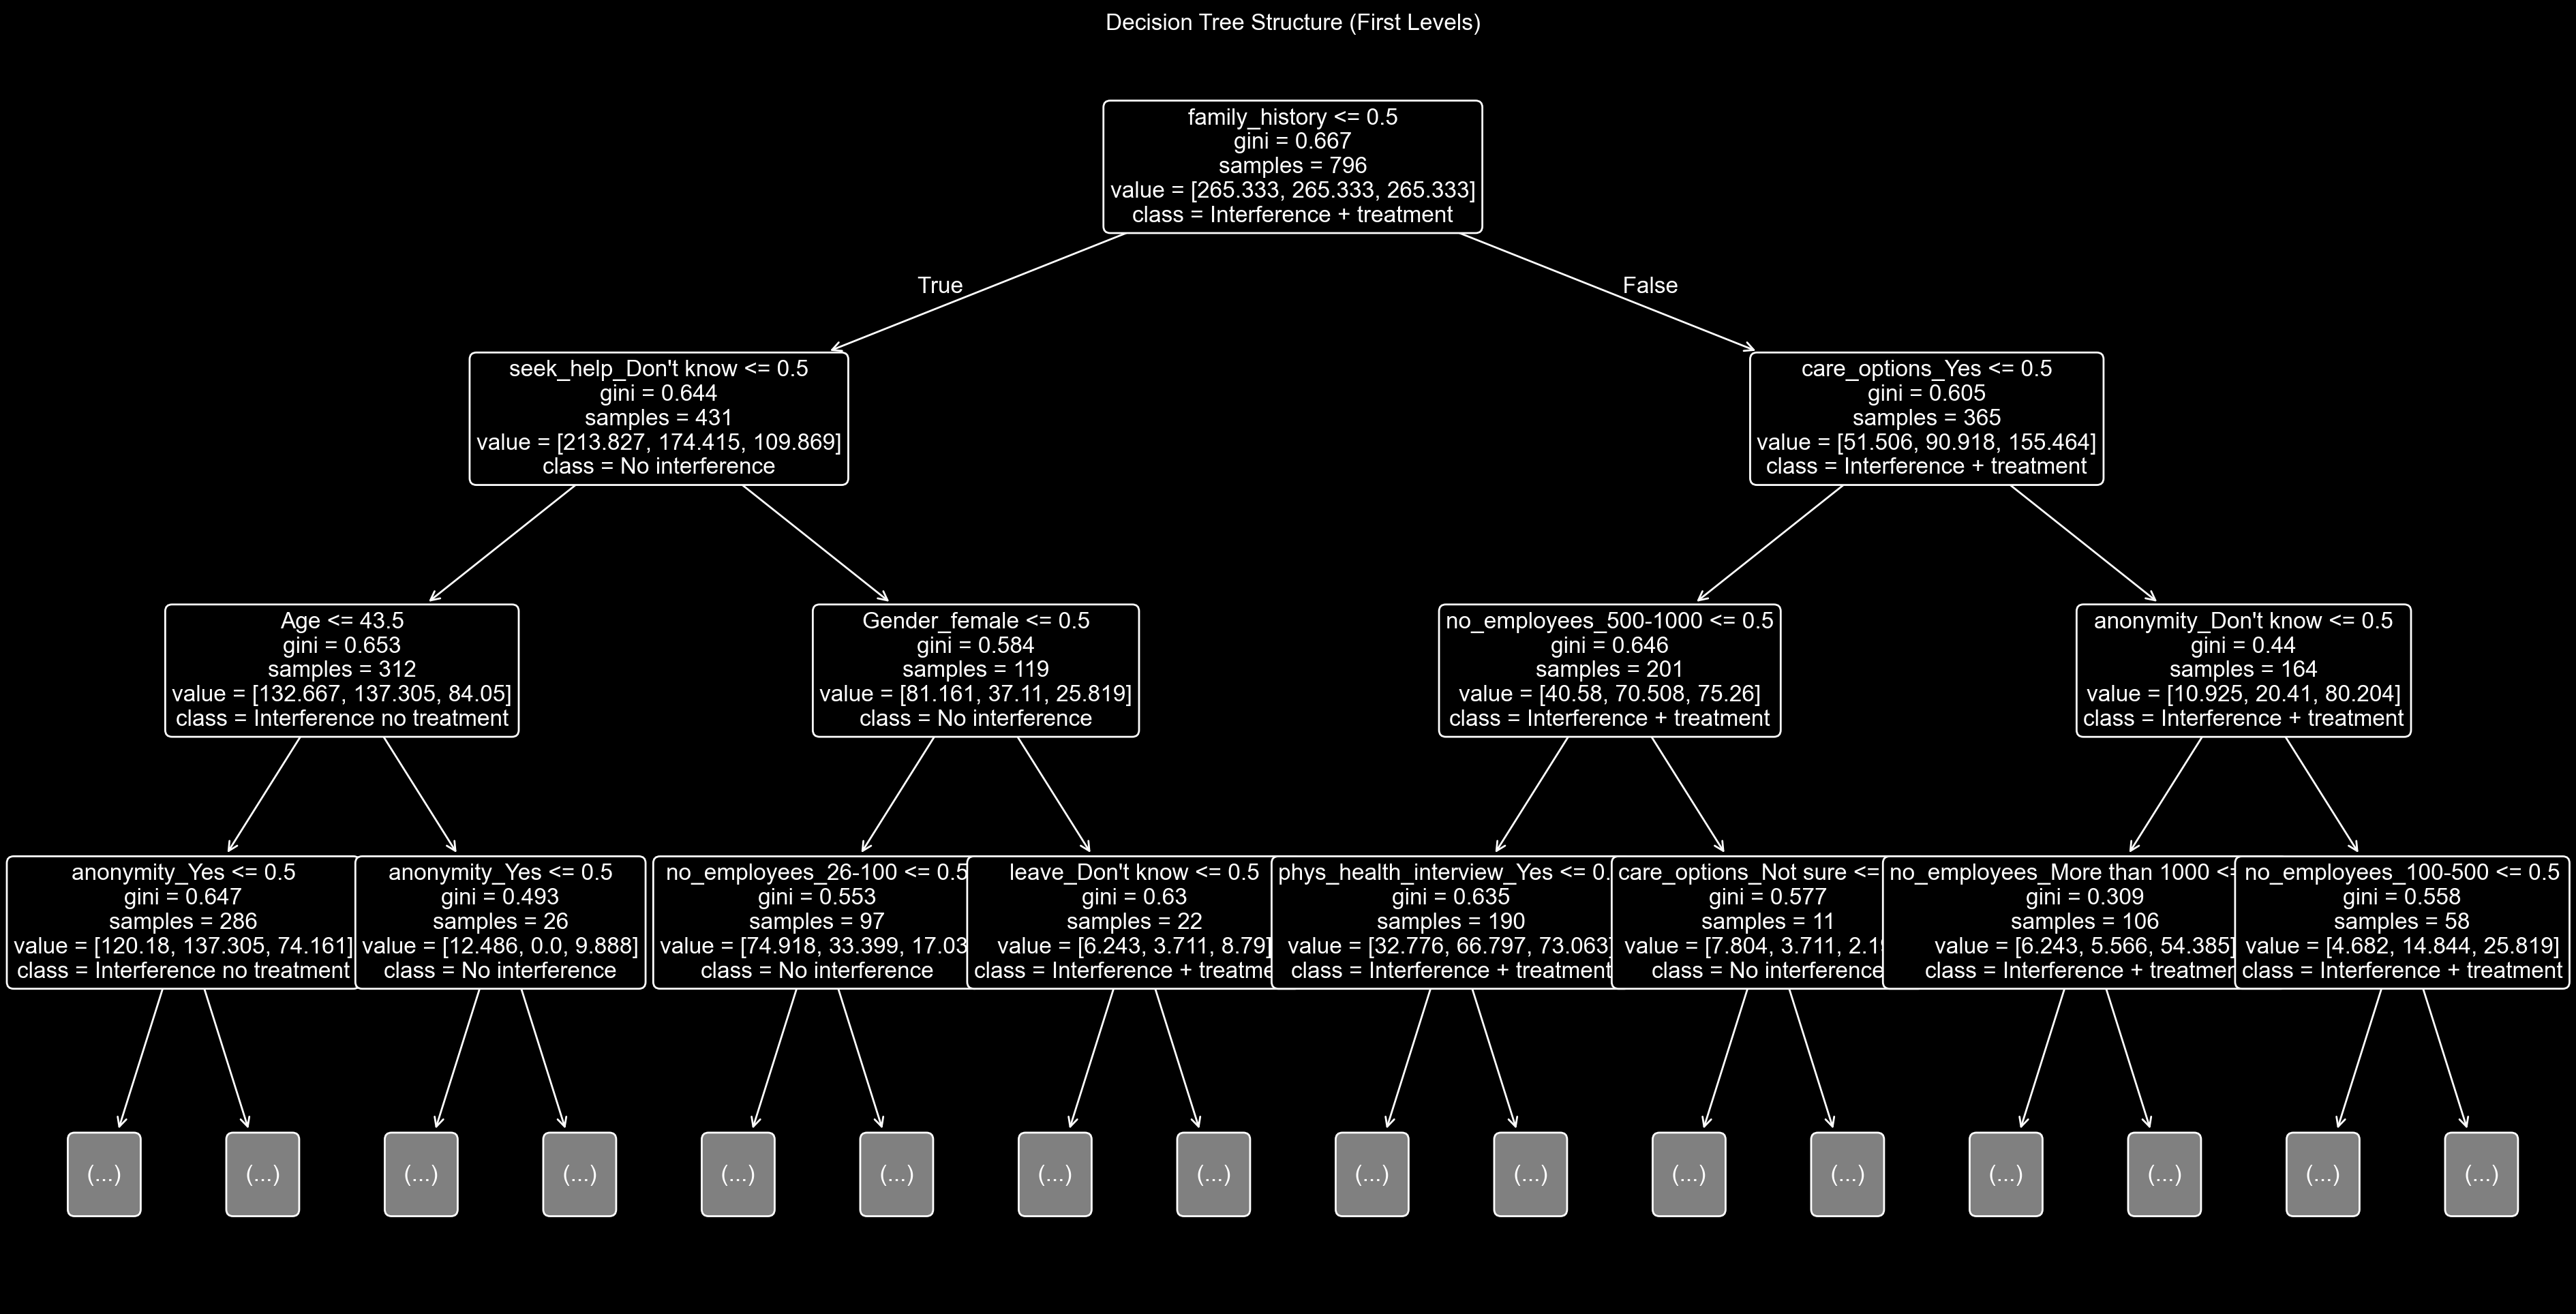

In [18]:
# Import function to visualize the decision tree structure
from sklearn.tree import plot_tree

# Create a large figure for better readability
# - figsize controls size
# - dpi increases resolution (important for thesis-quality figures)
plt.figure(figsize=(24,12), dpi=200)

# Plot the trained Decision Tree
# - feature_names: names of input variables used in splits
# - class_names: labels for target classes (used in leaf nodes)
# - rounded=True: improves visual aesthetics
# - max_depth=3: only show top levels for interpretability
# - fontsize: controls text size in the plot
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No interference","Interference no treatment","Interference + treatment"],
    rounded=True,
    max_depth=3,
    fontsize=12
)

# Add title to the visualization
plt.title("Decision Tree Structure (First Levels)")

# Display the plot
plt.show()

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "f1_macro":    make_scorer(f1_score, average="macro"),
    "f1_weighted": make_scorer(f1_score, average="weighted"),
}

models = {
    "Logistic Regression": logreg,
    "Decision Tree":       tree,
    "Random Forest":       rf,
    "XGBoost":             xgb,
}

cv_results = {}
for name, model in models.items():
    # F1 scores via cross_validate
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    # AUC via cross_val_predict (more reliable for multiclass OvR)
    y_prob_cv = cross_val_predict(
        model, X, y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )
    auc = roc_auc_score(y, y_prob_cv, multi_class="ovr", average="macro")

    cv_results[name] = {
        "F1 Macro (mean)":    round(scores["test_f1_macro"].mean(), 3),
        "F1 Macro (std)":     round(scores["test_f1_macro"].std(),  3),
        "F1 Weighted (mean)": round(scores["test_f1_weighted"].mean(), 3),
        "F1 Weighted (std)":  round(scores["test_f1_weighted"].std(),  3),
        "AUC OvR":            round(auc, 3),
    }

cv_df = pd.DataFrame(cv_results).T
print(cv_df)

                     F1 Macro (mean)  F1 Macro (std)  F1 Weighted (mean)  \
Logistic Regression            0.457           0.034               0.550   
Decision Tree                  0.408           0.027               0.483   
Random Forest                  0.470           0.015               0.597   
XGBoost                        0.441           0.020               0.577   

                     F1 Weighted (std)  AUC OvR  
Logistic Regression              0.027    0.685  
Decision Tree                    0.028    0.640  
Random Forest                    0.012    0.696  
XGBoost                          0.016    0.691  


In [25]:
results = pd.DataFrame([
    {"Model": "Logistic Regression", "Macro F1": macro_f1, "Weighted F1": weighted_f1},
    {"Model": "Decision Tree", "Macro F1": macro_f1_tree, "Weighted F1": weighted_f1_tree},
    {"Model": "Random Forest", "Macro F1": macro_f1_rf, "Weighted F1": weighted_f1_rf},
    {"Model": "XGBoost", "Macro F1": macro_f1_xgb, "Weighted F1": weighted_f1_xgb}
])

print(results)


                 Model  Macro F1  Weighted F1
0  Logistic Regression  0.509669     0.574226
1        Decision Tree  0.458189     0.529481
2        Random Forest  0.490606     0.597644
3              XGBoost  0.456947     0.581411


In [26]:
results = pd.DataFrame([
    {
        "Model":                "Logistic Regression",
        "Macro F1 (test)":      round(macro_f1, 3),
        "Weighted F1 (test)":   round(weighted_f1, 3),
        "CV Macro F1":          cv_df.loc["Logistic Regression", "F1 Macro (mean)"],
        "CV Macro F1 std":      cv_df.loc["Logistic Regression", "F1 Macro (std)"],
        "CV Weighted F1":       cv_df.loc["Logistic Regression", "F1 Weighted (mean)"],
        "AUC OvR":              cv_df.loc["Logistic Regression", "AUC OvR"],
    },
    {
        "Model":                "Decision Tree",
        "Macro F1 (test)":      round(macro_f1_tree, 3),
        "Weighted F1 (test)":   round(weighted_f1_tree, 3),
        "CV Macro F1":          cv_df.loc["Decision Tree", "F1 Macro (mean)"],
        "CV Macro F1 std":      cv_df.loc["Decision Tree", "F1 Macro (std)"],
        "CV Weighted F1":       cv_df.loc["Decision Tree", "F1 Weighted (mean)"],
        "AUC OvR":              cv_df.loc["Decision Tree", "AUC OvR"],
    },
    {
        "Model":                "Random Forest",
        "Macro F1 (test)":      round(macro_f1_rf, 3),
        "Weighted F1 (test)":   round(weighted_f1_rf, 3),
        "CV Macro F1":          cv_df.loc["Random Forest", "F1 Macro (mean)"],
        "CV Macro F1 std":      cv_df.loc["Random Forest", "F1 Macro (std)"],
        "CV Weighted F1":       cv_df.loc["Random Forest", "F1 Weighted (mean)"],
        "AUC OvR":              cv_df.loc["Random Forest", "AUC OvR"],
    },
    {
        "Model":                "XGBoost",
        "Macro F1 (test)":      round(macro_f1_xgb, 3),
        "Weighted F1 (test)":   round(weighted_f1_xgb, 3),
        "CV Macro F1":          cv_df.loc["XGBoost", "F1 Macro (mean)"],
        "CV Macro F1 std":      cv_df.loc["XGBoost", "F1 Macro (std)"],
        "CV Weighted F1":       cv_df.loc["XGBoost", "F1 Weighted (mean)"],
        "AUC OvR":              cv_df.loc["XGBoost", "AUC OvR"],
    },
])

results = results.set_index("Model")
print(results)

                     Macro F1 (test)  Weighted F1 (test)  CV Macro F1  \
Model                                                                   
Logistic Regression            0.510               0.574        0.457   
Decision Tree                  0.458               0.529        0.408   
Random Forest                  0.491               0.598        0.470   
XGBoost                        0.457               0.581        0.441   

                     CV Macro F1 std  CV Weighted F1  AUC OvR  
Model                                                          
Logistic Regression            0.034           0.550    0.685  
Decision Tree                  0.027           0.483    0.640  
Random Forest                  0.015           0.597    0.696  
XGBoost                        0.020           0.577    0.691  


In [ ]:
## Baseline Models — Results Summary (Mental Health in Tech)

### Dataset
# - 995 samples after filtering rows with missing target variables
# - 43 features after reference category dropping
# - Target: combined_target (0 = no interference, 1 = interference/no treatment,
#   2 = interference + treatment)
# - Class distribution: 60.6% / 21.4% / 18.0% — moderate imbalance addressed
#   via class_weight="balanced"

### Model Configuration
# Hyperparameters were set using principled defaults informed by the literature
# and kept consistent across all datasets. No dataset-specific tuning was performed,
# as the primary goal is comparative evaluation of modeling approaches rather than
# maximizing predictive performance on any single dataset.

### Key Findings
# - Random Forest achieves the best overall performance (CV Macro F1: 0.470,
#   AUC: 0.696) with the lowest variance (std: 0.015), suggesting stable
#   generalization.
# - Logistic Regression is competitive (CV Macro F1: 0.457, AUC: 0.685) and
#   achieves the best test-set Macro F1 (0.510), indicating it handles minority
#   classes well under balanced weighting.
# - All models struggle most with Class 1 (interference, no treatment) — the
#   smallest and arguably most psychologically ambiguous class.
# - family_history is the most consistently important feature across all four
#   models, a finding with clear psychological interpretability.
# - Test set Macro F1 is systematically higher than CV Macro F1 across all models
#   (~0.04–0.05 gap), suggesting mild optimism in single-split evaluation —
#   confirming the value of cross-validation.